# Hw 5 problem 2
Below is the python notebook from the in-class demonstration in Lec 12.
Your task for this problem is the following:
1. change the neural network model so that `w2` is frozen at a random initialization (while `W1` is still trainable)
2. demonstrate that the objective function is still non-convex (you may have to change the random seed)

In [1]:
import numpy as np
np.random.seed(1000) # you may have to change this random seed to demonstrate non-convexity

n = 20
X = np.random.randn( n , 2 )
w_true = np.random.randn(2)
y = np.sign(X @ w_true)



#
# def logistic_regression_obj(w):
#     return np.log( 1 + np.exp ( y * (X @ w)) ).mean()

# need to update to a neural network model

# Relu( X @ W1 ) @ w2

h = 16 # number of hidden neurons
def NN_obj(theta):
    # theta will be a tuple
    # theta[0] = W1
    # theta[1] = w2
    W1 = theta[0]
    w2 = theta[1]
    
    yhat = np.maximum( (X @ W1), 0) @ w2 # predictions
    return np.log( 1 + np.exp( y * yhat)).mean()


theta1 = ( np.random.randn(2, h),  np.random.randn(h))
theta2 = ( np.random.randn(2, h),  np.random.randn(h))

NN_obj(theta1)

np.float64(1.9510189645913172)

In [2]:
c_list = np.linspace(0,1)

theta_list = [ (c * theta1[0] + (1-c) * theta2[0],
                c * theta1[1] + (1-c) * theta2[1]) for c in c_list ]

obj_list = [ NN_obj(theta) for theta in theta_list ]

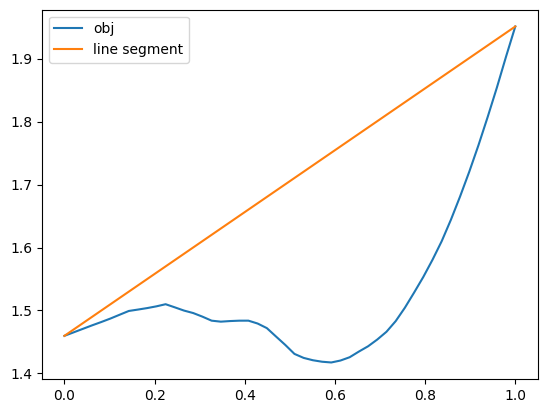

In [3]:
import matplotlib.pyplot as plt
plt.plot(c_list, obj_list, label = 'obj')
plt.plot([0,1], [obj_list[0], obj_list[-1]], label='line segment')
plt.legend()

## My answer

### Imports and dataset

In [25]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(4)      
n = 40
d = 2
h = 5
K = 3

# input data
X = np.random.randn(n, d)

# true weights for generating labels
W_true1 = np.random.randn(d, h)
b_true1 = np.random.randn(h)
W_true2 = np.random.randn(h, K)
b_true2 = np.random.randn(K)

# generate logits and labels
H = np.tanh(X @ W_true1 + b_true1)
logits = H @ W_true2 + b_true2
exp_logits = np.exp(logits)
probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)
y = np.array([np.random.choice(K, p=probs[i]) for i in range(n)])


### Define the non convex neural network objective

In [26]:
def unpack(theta):
    # theta is a tuple (W1, b1, W2, b2)
    return theta

def NN_obj(theta):
    W1, b1, W2, b2 = theta
    H = np.tanh(X @ W1 + b1)
    logits = H @ W2 + b2
    exp_logits = np.exp(logits)
    P = exp_logits / exp_logits.sum(axis=1, keepdims=True)
    loss = -np.log(P[np.arange(n), y]).mean()
    return loss


### Create two random parameter sets and evaluate the loss along the line segment

In [27]:
# random initial parameter sets
theta1 = (
    np.random.randn(d, h),
    np.random.randn(h),
    np.random.randn(h, K),
    np.random.randn(K)
)

theta2 = (
    np.random.randn(d, h),
    np.random.randn(h),
    np.random.randn(h, K),
    np.random.randn(K)
)

# line segment between two neural network parameter sets
c_list = np.linspace(0, 1, 50)

theta_list = [
    (
        c * theta1[0] + (1 - c) * theta2[0],
        c * theta1[1] + (1 - c) * theta2[1],
        c * theta1[2] + (1 - c) * theta2[2],
        c * theta1[3] + (1 - c) * theta2[3],
    )
    for c in c_list
]

obj_list = [NN_obj(theta) for theta in theta_list]


### Plot showing the objective is non convex

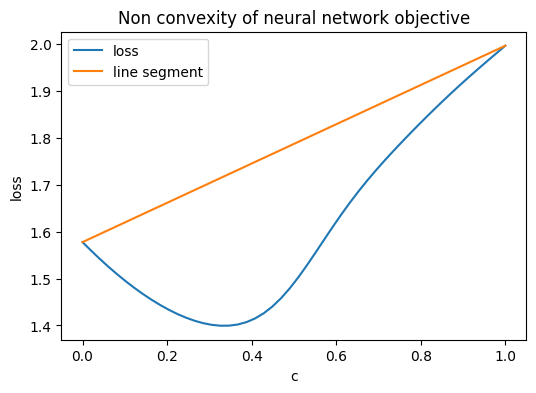

In [28]:
plt.figure(figsize=(6,4))
plt.plot(c_list, obj_list, label="loss")
plt.plot([0,1], [obj_list[0], obj_list[-1]], label="line segment")
plt.xlabel("c")
plt.ylabel("loss")
plt.title("Non convexity of neural network objective")
plt.legend()
plt.show()
